In [ ]:
import numpy as np
import copy
import nn
import dataset as ds
from matplotlib import pyplot as plt
import logging

logging.basicConfig(level=logging.ERROR, format="%(message)s")
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
n = 10_000
data = ds.TrainingData.spiral(num_points=n, seed=42)

In [ ]:
input_layer_size = 2
hidden_layer_size = 20

np.random.seed(42)

l1 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, input_layer_size))
    * np.sqrt(2 / input_layer_size)
)
act1 = nn.Max0()
l2 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, hidden_layer_size))
    * np.sqrt(2 / hidden_layer_size)
)
act2 = nn.Max0()
l3 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, hidden_layer_size))
    * np.sqrt(2 / hidden_layer_size)
)
act3 = nn.Max0()
l4 = nn.Linear(
    1 / np.sqrt(hidden_layer_size) * np.random.normal(size=(1, hidden_layer_size))
)
act4 = nn.MapTo01()

layers = [l1, act1, l2, act2, l3, act3, l4, act4]
neural_network = nn.NN(layers)

loss_function = nn.CrossEntropyLoss()

In [18]:
def make_plot(neural_network, data, num_points):
    random_sample = list(range(num_points))
    all_float_predictions = np.array([neural_network.run(x) for x in data.input_features]).flatten()
    all_predictions = all_float_predictions > 0.5

    plt.rcParams["figure.figsize"] = (10, 10)

    data.plot_data()

    sample_points_for_prediction = np.array([data.input_features[i, :] for i in random_sample])
    sample_predictions = (
        np.array([neural_network.run(x) for x in sample_points_for_prediction]).flatten()
        > 0.5
    )
    plt.scatter(
        sample_points_for_prediction[~data.answers[random_sample].astype(bool), 0],
        sample_points_for_prediction[~data.answers[random_sample].astype(bool), 1],
        color="r",
        s=200,
        edgecolors="black",
        linewidths=1.5,
    )
    plt.scatter(
        sample_points_for_prediction[data.answers[random_sample].astype(bool), 0],
        sample_points_for_prediction[data.answers[random_sample].astype(bool), 1],
        color="g",
        s=200,
        edgecolors="black",
        linewidths=1.5,
    )
    plt.show()


Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.
findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='/home/kzhu/curling/venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='/home/kzhu/curling/venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
findfont: score(FontEntry(fname='/home/kzhu/curling/venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: scor

0.13433715815490052


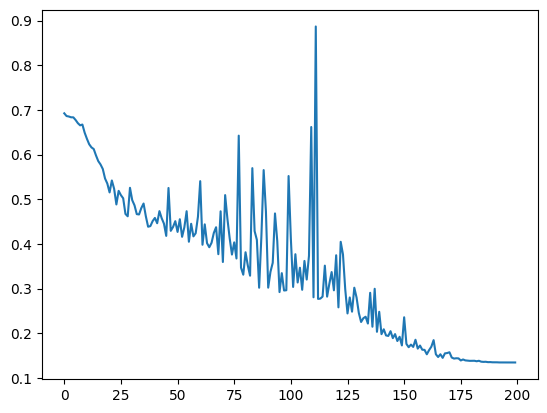

In [7]:
losses = []
num_points_per_batch = 100
num_iters = 200

for i in range(num_iters):
    lr = 1 * 0.5 * (1 + np.cos(np.pi * i / num_iters))
    for batch in data.shuffle_batches(num_points_per_batch, seed=None):
        neural_network.train(
            batch,
            loss_function,
            lr,
            0,
        )

    losses.append(neural_network.get_average_loss(data.input_features, data.answers, loss_function))

plt.plot(losses)
print(losses[-1])

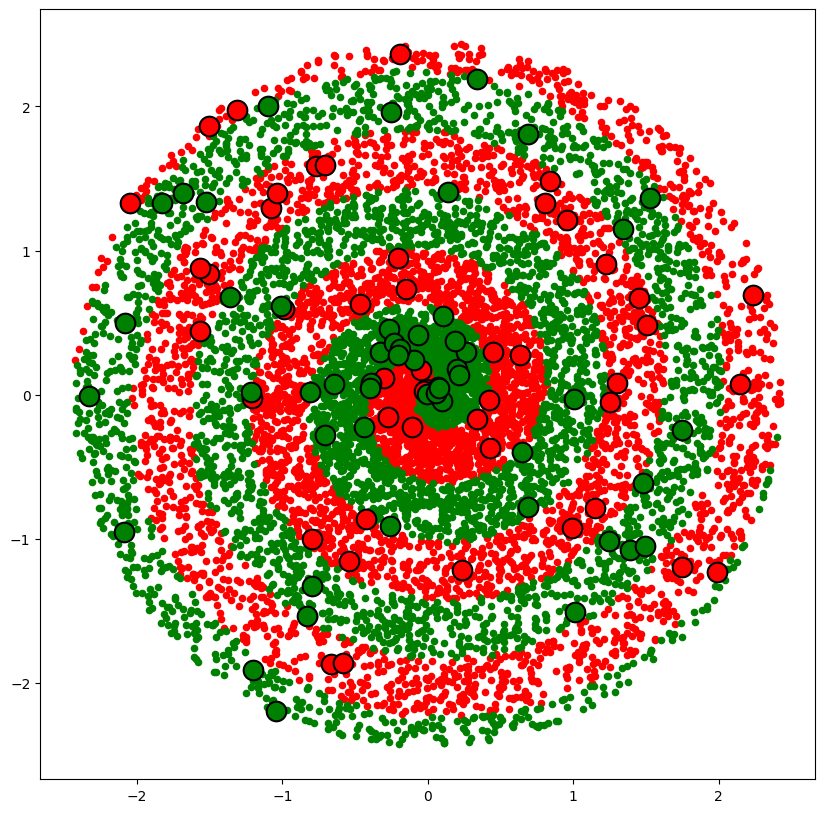

In [19]:
make_plot(neural_network, data, 100)

In [21]:
for i in range(len(data.answers)):
    print(i, neural_network.run(data.input_features[i, :]), data.answers[i])

0 [0.01219604] 0.0
1 [0.0057789] 0.0
2 [0.9815614] 1.0
3 [0.76558815] 1.0
4 [1.30872196e-05] 0.0
5 [1.2867718e-07] 0.0
6 [0.00921637] 0.0
7 [0.49126092] 0.0
8 [0.99858409] 1.0
9 [1.19677603e-05] 0.0
10 [0.95850585] 1.0
11 [2.12266769e-05] 0.0
12 [0.99999998] 1.0
13 [0.58734331] 1.0
14 [0.80312865] 1.0
15 [1.02463613e-08] 0.0
16 [0.80868697] 1.0
17 [0.9970446] 1.0
18 [0.99786668] 1.0
19 [0.99716151] 1.0
20 [0.99949545] 1.0
21 [5.08316773e-10] 0.0
22 [0.81320446] 1.0
23 [0.98317404] 1.0
24 [0.99943723] 1.0
25 [5.46055966e-11] 0.0
26 [0.68741495] 1.0
27 [0.99999959] 1.0
28 [0.84359549] 1.0
29 [0.04004103] 0.0
30 [0.46793821] 1.0
31 [0.99011155] 1.0
32 [0.99532772] 1.0
33 [0.99999998] 1.0
34 [0.74936165] 0.0
35 [0.87070937] 1.0
36 [0.75958086] 1.0
37 [0.69129236] 1.0
38 [0.00415731] 0.0
39 [0.02912772] 0.0
40 [0.00010979] 0.0
41 [0.64869308] 1.0
42 [0.00122994] 0.0
43 [0.89687493] 1.0
44 [0.44932436] 1.0
45 [0.52021897] 0.0
46 [0.00291259] 0.0
47 [0.96271825] 1.0
48 [1.61059286e-05] 0.0
49

In [22]:
x = data.input_features[3, :]
neural_network.debug_gradients(x, data.answers[3], loss_function)

{'inputs': array([0.07279119, 0.05253886]),
 'prediction': array([0.76558815]),
 'actual': np.float64(1.0),
 'initial_output_gradient': array([-0.23441185]),
 'input_gradients_by_layer': [array([-7.26552481,  8.8528413 ]),
  array([ 0.2039698 , -0.        , -0.        ,  0.        ,  0.06715678,
          0.12730226,  0.        ,  0.0652414 ,  0.48434403,  0.        ,
         -0.81855987, -1.70094006, -0.        ,  0.08022689, -0.32170309,
          1.48699127, -0.        ,  0.        ,  0.        ,  0.10984171]),
  array([ 0.2039698 , -2.79684779, -0.44270635,  1.16506985,  0.06715678,
          0.12730226,  1.87927959,  0.0652414 ,  0.48434403,  1.96864114,
         -0.81855987, -1.70094006, -1.38232369,  0.08022689, -0.32170309,
          1.48699127, -0.61460091,  1.04120168,  1.45070828,  0.10984171]),
  array([-0.19962565, -0.0608936 ,  0.        ,  0.15213221,  0.63783719,
         -0.0225428 , -0.        ,  0.09779515,  0.        ,  0.2603627 ,
         -0.        , -0.1603052 

In [23]:
x = data.input_features[3, :]
neural_network.debug_gradients(x, data.answers[3], nn.SquaredErrorLoss())

{'inputs': array([0.07279119, 0.05253886]),
 'prediction': array([0.76558815]),
 'actual': np.float64(1.0),
 'initial_output_gradient': array([-0.4688237]),
 'input_gradients_by_layer': [array([-14.53104962,  17.7056826 ]),
  array([ 0.4079396 , -0.        , -0.        ,  0.        ,  0.13431355,
          0.25460453,  0.        ,  0.1304828 ,  0.96868806,  0.        ,
         -1.63711974, -3.40188011, -0.        ,  0.16045377, -0.64340618,
          2.97398255, -0.        ,  0.        ,  0.        ,  0.21968342]),
  array([ 0.4079396 , -5.59369558, -0.8854127 ,  2.33013971,  0.13431355,
          0.25460453,  3.75855918,  0.1304828 ,  0.96868806,  3.93728228,
         -1.63711974, -3.40188011, -2.76464738,  0.16045377, -0.64340618,
          2.97398255, -1.22920181,  2.08240336,  2.90141655,  0.21968342]),
  array([-0.3992513 , -0.12178721,  0.        ,  0.30426441,  1.27567439,
         -0.04508559, -0.        ,  0.1955903 ,  0.        ,  0.52072539,
         -0.        , -0.3206103

In [24]:
neural_network.layers[4].weights

array([[ 1.17135405e-01, -1.05316404e-02, -6.53782597e-01,
        -3.07527537e-02, -4.12521771e-01,  2.05858623e-01,
         1.12043001e-01, -2.97228621e-01, -1.78547424e-01,
        -3.34952757e-01, -2.29066476e-02,  2.96804121e-01,
        -3.11738271e-01,  1.57990797e-01, -1.69485869e-01,
        -2.50729567e-01, -3.70460789e-02, -3.28272078e-01,
        -1.75079283e-01, -3.79483844e-01],
       [ 5.33826310e-01, -3.13785290e-02, -2.35970315e-01,
        -1.30631254e-01, -9.17226866e-02, -2.71982237e-02,
        -4.37634321e-02,  2.63424960e-01, -4.84206492e-01,
        -1.98777177e-01, -1.69136530e-01, -7.16014016e-01,
        -5.31031789e-01,  3.19343073e-01,  5.73342448e-01,
         4.51480775e-03,  1.39496878e-01, -6.19047389e-02,
         9.61039746e-01,  2.75009463e-01],
       [-2.79166589e-01, -3.11066480e+00, -5.34387534e-01,
         7.26413990e-01, -2.39179107e-01, -7.13486499e-01,
        -1.14810594e+00, -4.60330776e-01,  7.53262362e-01,
         2.62639847e-01, -4.2

In [25]:
neural_network.layers[0].weights @ data.input_features[2, :]

array([-0.08136784, -0.81480198,  0.42583407, -1.55928799,  0.40964012,
        0.23176191,  0.44550921,  0.9672886 ,  0.494109  ,  1.34440925,
       -0.76820522, -0.04954308,  0.66853409,  0.78340471,  0.11205619,
        0.01967209,  0.52225829, -0.79848947, -0.23793068,  1.01670276])

In [26]:
data.input_features[:3]

array([[-0.76764672,  1.58703649],
       [-0.70593649,  1.59025307],
       [-0.44051251, -0.22330566]])

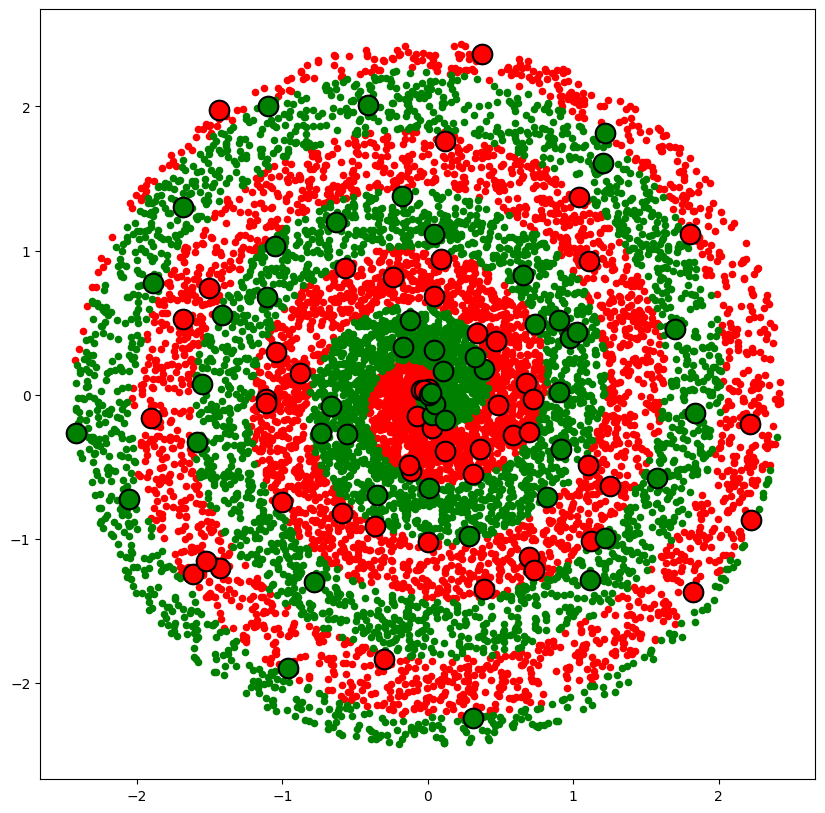

In [30]:
random_sample = np.random.choice(data.input_features.shape[0], size=100, replace=False)
sample_points_for_prediction = np.array([data.input_features[i, :] for i in random_sample])
sample_predictions = (
    np.array([neural_network.run(x) for x in sample_points_for_prediction]).flatten()
    > 0.5
)

plt.rcParams["figure.figsize"] = (10, 10)

data.plot_data()


plt.scatter(
    sample_points_for_prediction[~sample_predictions, 0],
    sample_points_for_prediction[~sample_predictions, 1],
    color="r",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)
plt.scatter(
    sample_points_for_prediction[sample_predictions, 0],
    sample_points_for_prediction[sample_predictions, 1],
    color="g",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)